# CT EDA -- Mayo Clinic Sparse-View CT
Run this **before training** to verify data access and inspect images.

**Location:** `ct/notebooks/` -- project root is two levels up (`../..`).

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Project root is two levels above this notebook (ct/notebooks -> ct -> root)
PROJECT_ROOT = os.path.abspath("../..")
sys.path.insert(0, PROJECT_ROOT)

from config import CT, CT_DATA_DIR

print(f"Project root : {PROJECT_ROOT}")
print(f"CT_DATA_DIR  : {CT_DATA_DIR}")
print(f"Box token set: {bool(CT['box_token'])}")


Project root : c:\Users\Shahu Patil\Desktop\CS 736
CT_DATA_DIR  : C:\Users\Shahu Patil\Desktop\CS 736\ct_cache\full_3mm\full_3mm
Box token set: True


## 0. Verify Box Access (fetches 2 slices -- caches to disk)

In [2]:
# Token is read automatically from CT["box_token"] in config.py
# If you get a 401 error:
#   1. Regenerate at https://developer.box.com  (expires every 60 min)
#   2. Paste the new token into config.py  CT["box_token"] = "new_token"
#   3. Restart the Jupyter kernel and re-run
if not CT["box_token"]:
    raise RuntimeError(
        "Box token not set.\n"
        "Open config.py and set: CT[\"box_token\"] = \"your_token\"\n"
        "Regenerate at https://developer.box.com (expires every 60 min).\n"
        "After editing config.py, restart the kernel and re-run."
    )

from ct.dataset import BoxCTDataset

ds = BoxCTDataset(
    patients=[CT["train_patients"][0]],
    slices_per_patient=2,
)
fbp, sino, gt = ds[0]
print(f"Box streaming OK -- fbp shape: {fbp.shape}")

Fetching slices from Box zip via HTTP range requests …
  (only downloads 2 slices/patient — no full zip)
  L067: fetched 2 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L067

Dataset ready: 2 slices | 60-view sparse CT


c:\Users\Shahu Patil\miniconda3\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


Box streaming OK -- fbp shape: torch.Size([1, 128, 128])


## 1. Patient / Slice Inventory

In [3]:
from pathlib import Path

cache_root = Path(PROJECT_ROOT) / "ct_cache" / "slices"
inventory  = {}

print(f"{'Patient':10s} {'Split':6s} {'Cached Slices':>14s}")
print("-" * 34)
for pid in CT["train_patients"] + CT["val_patients"] + CT["test_patients"]:
    pid_dir = cache_root / pid
    slices  = sorted(pid_dir.glob("*.IMA")) if pid_dir.exists() else []
    inventory[pid] = slices
    split = ("TRAIN" if pid in CT["train_patients"] else
             "VAL"   if pid in CT["val_patients"]   else "TEST")
    print(f"{pid:10s} {split:6s} {len(slices):14d}")


Patient    Split   Cached Slices
----------------------------------
L067       TRAIN               2
L096       TRAIN               0
L109       TRAIN               0
L143       TRAIN               0
L192       TRAIN               0
L286       TRAIN               0
L291       TRAIN               0
L310       TRAIN               0
L333       VAL                 0
L506       TEST                0


## 2. Sample Slices -- Ground Truth

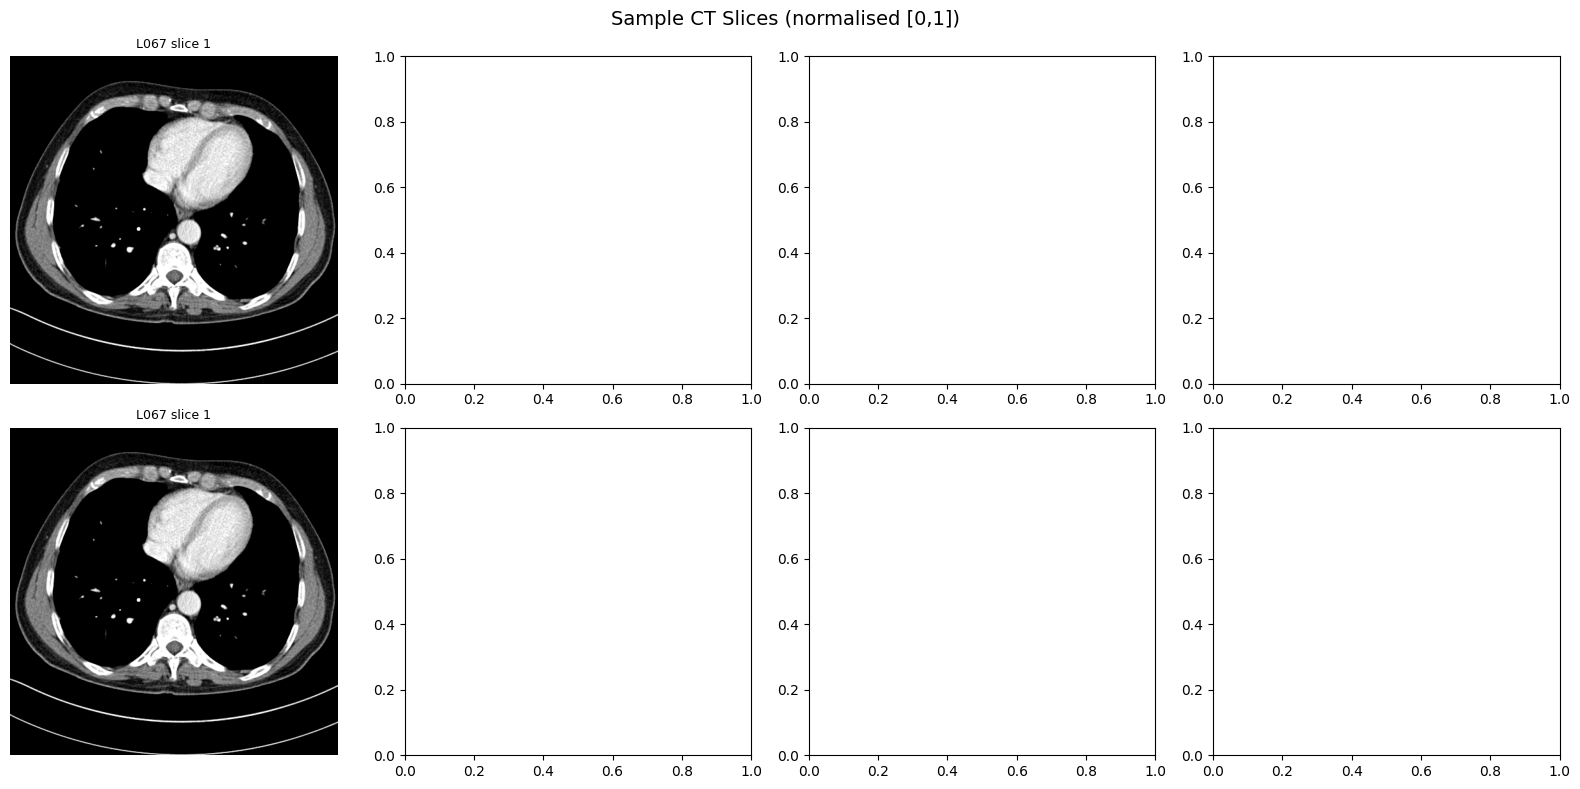

In [4]:
from ct.dataset import load_ima_file

patients_to_show = [p for p in CT["train_patients"] if inventory.get(p)][:4]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, pid in enumerate(patients_to_show):
    slices = inventory[pid]
    mid    = len(slices) // 2
    for row, idx in enumerate([mid, min(mid + 1, len(slices) - 1)]):
        img = load_ima_file(slices[idx])
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{pid} slice {idx}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Sample CT Slices (normalised [0,1])", fontsize=14)
plt.tight_layout()
plt.savefig("ct_eda_samples.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Effect of Number of Views on FBP Quality

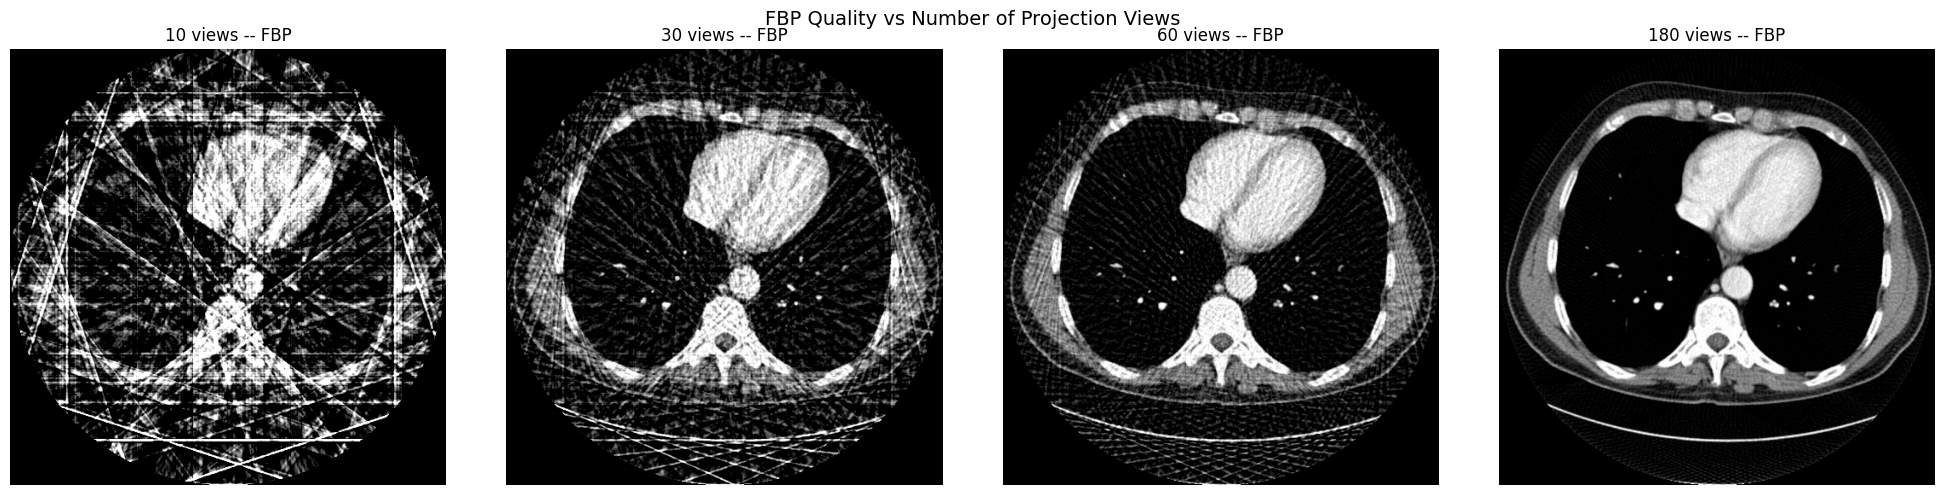

In [5]:
from ct.dataset import make_sparse_sinogram

pid    = patients_to_show[0]
slices = inventory[pid]
gt_img = load_ima_file(slices[len(slices) // 2])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, n_v in zip(axes, [10, 30, 60, 180]):
    _, fbp = make_sparse_sinogram(gt_img, n_v)
    ax.imshow(fbp, cmap="gray")
    ax.set_title(f"{n_v} views -- FBP", fontsize=12)
    ax.axis("off")

plt.suptitle("FBP Quality vs Number of Projection Views", fontsize=14)
plt.tight_layout()
plt.savefig("ct_eda_fbp_views.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Sinogram Visualisation (60 views)

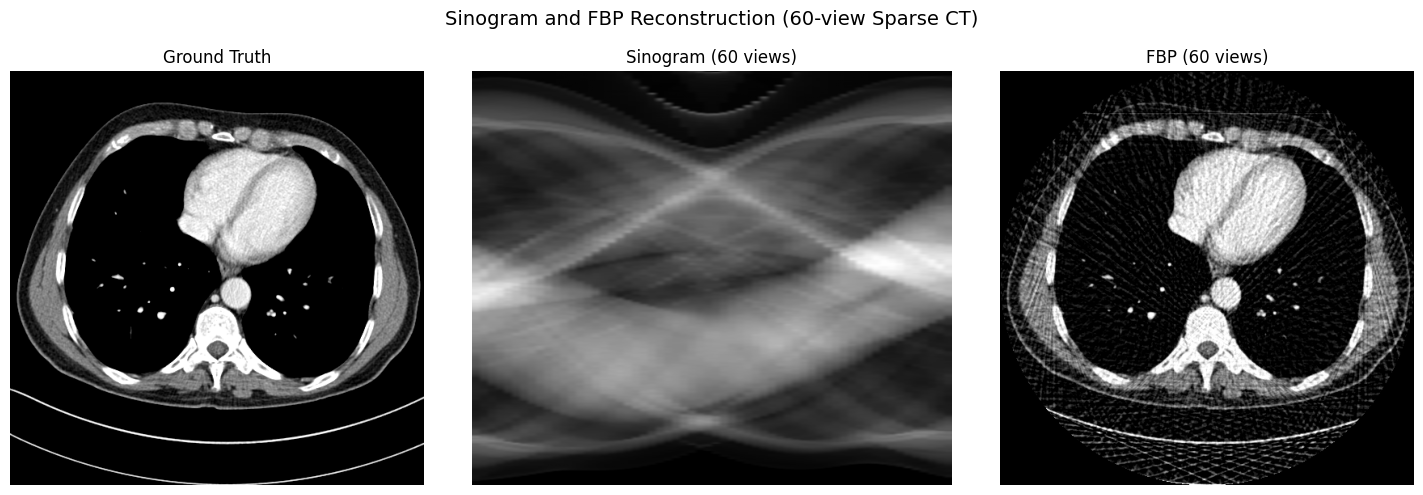

In [6]:
sino_60, fbp_60 = make_sparse_sinogram(gt_img, 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_img,  cmap="gray");               axes[0].set_title("Ground Truth");        axes[0].axis("off")
axes[1].imshow(sino_60, cmap="gray", aspect="auto"); axes[1].set_title("Sinogram (60 views)"); axes[1].axis("off")
axes[2].imshow(fbp_60,  cmap="gray");               axes[2].set_title("FBP (60 views)");      axes[2].axis("off")

plt.suptitle("Sinogram and FBP Reconstruction (60-view Sparse CT)", fontsize=14)
plt.tight_layout()
plt.savefig("ct_eda_sinogram.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Pixel Intensity Histograms by Split

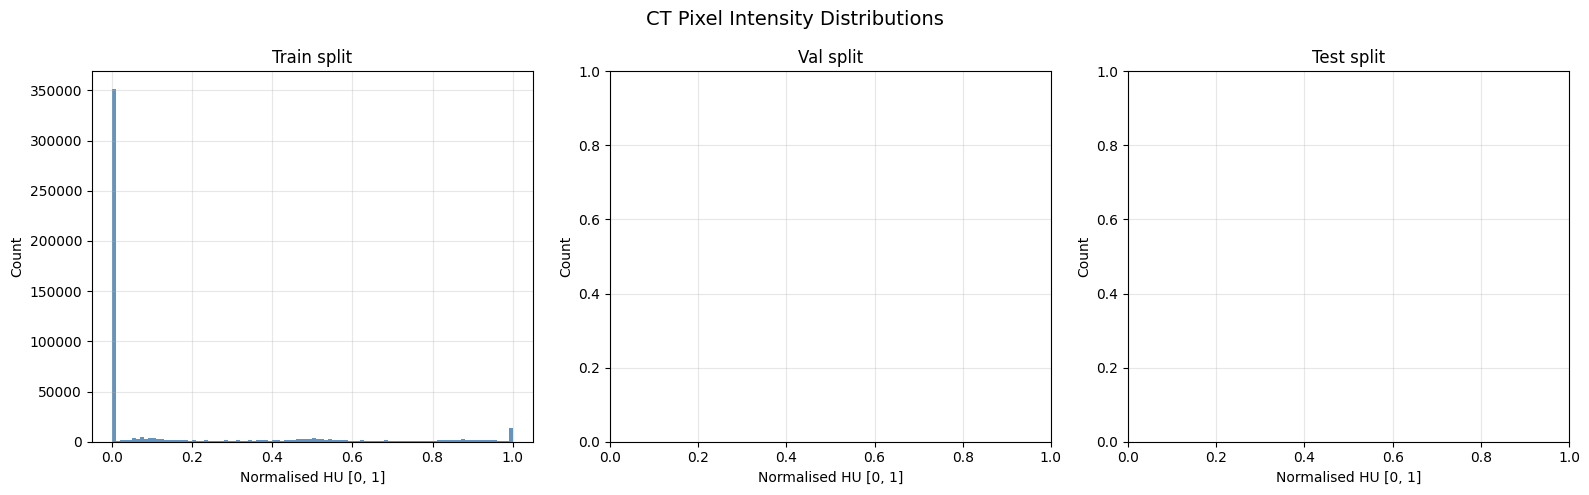

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (split_name, patients) in zip(
    axes,
    [("Train", CT["train_patients"]),
     ("Val",   CT["val_patients"]),
     ("Test",  CT["test_patients"])]
):
    sample_pix = []
    for pid in patients[:2]:
        for sl in inventory.get(pid, [])[:3]:
            sample_pix.extend(load_ima_file(sl).flatten().tolist())
    if sample_pix:
        ax.hist(sample_pix, bins=100, color="steelblue", alpha=0.85)
    ax.set_title(f"{split_name} split", fontsize=12)
    ax.set_xlabel("Normalised HU [0, 1]")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

plt.suptitle("CT Pixel Intensity Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("ct_eda_histograms.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. DataLoader Sanity Check

Building CT datasets …
  TRAIN:
Fetching slices from Box zip via HTTP range requests …
  (only downloads 30 slices/patient — no full zip)
  L067: fetched 30 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L067
  L096: fetched 30 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L096
  L109: fetched 30 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L109
  L143: fetched 30 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L143
  L192: fetched 30 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L192
  L286: fetched 30 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L286
  L291: fetched 30 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L291
  L310: fetched 30 slices → c:\Users\Shahu Patil\Desktop\CS 736\ct_cache\slices\L310

Dataset ready: 240 slices | 60-view sparse CT
  VAL:
Fetching slices from Box zip via HTTP range requests …
  (only downloads 10 slices/patient — no full zip)
  L333: fetched 10 sli

c:\Users\Shahu Patil\miniconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


FBP  shape: torch.Size([2, 1, 128, 128])  range [0.000, 1.000]
Sino shape: torch.Size([2, 1, 128, 60])
GT   shape: torch.Size([2, 1, 128, 128])  range [0.000, 1.000]


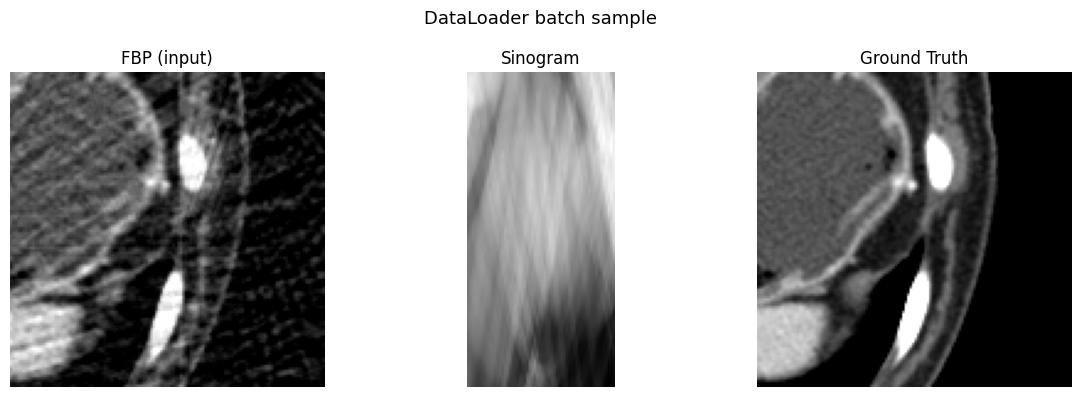

DataLoader OK


In [8]:
from ct.dataset import build_ct_loaders

# Token auto-read from CT["box_token"] in config.py
train_loader, val_loader, test_loader = build_ct_loaders()

fbp_b, sino_b, gt_b = next(iter(train_loader))
print(f"FBP  shape: {fbp_b.shape}  range [{fbp_b.min():.3f}, {fbp_b.max():.3f}]")
print(f"Sino shape: {sino_b.shape}")
print(f"GT   shape: {gt_b.shape}  range [{gt_b.min():.3f}, {gt_b.max():.3f}]")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes,
    [fbp_b[0, 0], sino_b[0, 0], gt_b[0, 0]],
    ["FBP (input)", "Sinogram", "Ground Truth"]):
    ax.imshow(img.numpy(), cmap="gray"); ax.set_title(title); ax.axis("off")
plt.suptitle("DataLoader batch sample", fontsize=13)
plt.tight_layout()
plt.savefig("ct_eda_dataloader.png", dpi=120, bbox_inches="tight")
plt.show()
print("DataLoader OK")

## 7. FBP Baseline Metrics on Test Set

In [9]:
import torch
from shared.metrics import compute_metrics

fbp_psnrs, fbp_ssims, fbp_rmses = [], [], []
with torch.no_grad():
    for fbp, sino, gt in test_loader:
        for p, g in zip(fbp.squeeze(1).numpy(), gt.squeeze(1).numpy()):
            m = compute_metrics(p, g)
            fbp_psnrs.append(m["PSNR"])
            fbp_ssims.append(m["SSIM"])
            fbp_rmses.append(m["RMSE"])

print(f"FBP baseline ({len(fbp_psnrs)} test slices):")
print(f"  PSNR : {np.mean(fbp_psnrs):.3f} +/- {np.std(fbp_psnrs):.3f} dB")
print(f"  SSIM : {np.mean(fbp_ssims):.4f} +/- {np.std(fbp_ssims):.4f}")
print(f"  RMSE : {np.mean(fbp_rmses):.5f} +/- {np.std(fbp_rmses):.5f}")


FBP baseline (10 test slices):
  PSNR : 21.625 +/- 0.187 dB
  SSIM : 0.4252 +/- 0.0077
  RMSE : 0.08296 +/- 0.00177
